In [2]:
# validation Random 16개 뽑아서 폴더 이동

import os
import shutil

src_image_folder = "/home/najo/NAS/DIP/datasets/meca_insertion/YOLO_train_top/images/train"     # 이미지가 있는 원본 폴더
dst_image_folder = "/home/najo/NAS/DIP/datasets/meca_insertion/YOLO_train_top/images/val"     # 이동할 대상 폴더
    
json_folder = "/home/najo/NAS/DIP/datasets/meca_insertion/YOLO_train_top/labels/val_json"
json_files = [f for f in os.listdir(json_folder) if f.endswith(".json")]

for json_file in json_files:
    image_filename = os.path.splitext(json_file)[0] + ".jpg"
    src_image_path = os.path.join(src_image_folder, image_filename)
    dst_image_path = os.path.join(dst_image_folder, image_filename)

    if os.path.exists(src_image_path):
        os.makedirs(dst_image_folder, exist_ok=True)
        shutil.move(src_image_path, dst_image_path)
        print(f"✔ {image_filename} 이동 완료")
    else:
        print(f"⚠ {image_filename} 없음")


✔ zed_49045152_right_1747201078.148.jpg 이동 완료
✔ zed_49045152_left_1747201077.836.jpg 이동 완료
✔ zed_49045152_left_1747201066.018.jpg 이동 완료
✔ zed_49045152_left_1746711971.179.jpg 이동 완료
✔ zed_49045152_left_1746711986.136.jpg 이동 완료
✔ zed_49045152_left_1747201062.165.jpg 이동 완료
✔ zed_49045152_right_1746711987.251.jpg 이동 완료
✔ zed_49045152_right_1747201063.479.jpg 이동 완료
✔ zed_49045152_left_1747201072.722.jpg 이동 완료
✔ zed_49045152_right_1747201073.059.jpg 이동 완료
✔ zed_49045152_right_1747201068.162.jpg 이동 완료
✔ zed_49045152_right_1747201057.135.jpg 이동 완료
✔ zed_49045152_right_1746711975.165.jpg 이동 완료
✔ zed_49045152_left_1747201056.789.jpg 이동 완료
✔ zed_49045152_right_1747201051.259.jpg 이동 완료
✔ zed_49045152_left_1747201051.558.jpg 이동 완료



image 1/1 /home/najo/NAS/RobotHuman_Co-work/datasets/Robot_data/Basler_acA1300-30gc__24051641__20240911_150924559_0573.tiff: 480x640 1 person, 1 bottle, 1 sink, 1 clock, 7.7ms
Speed: 1.7ms preprocess, 7.7ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)
Original image dtype: uint8


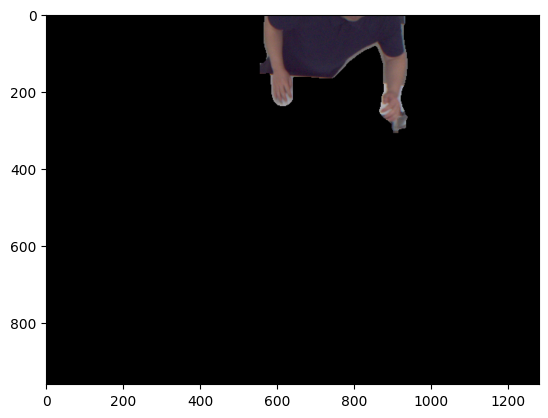

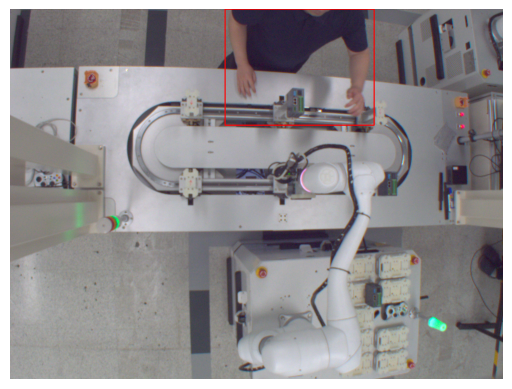

In [18]:
# 필요한 모듈 불러오기
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. 모델 로드 (YOLOv8 pre-trained segmentation 모델)
model = YOLO('yolov8n-seg.pt')  # 'yolov8n-seg.pt'는 경량 모델, 필요에 따라 'yolov8m-seg.pt'나 'yolov8l-seg.pt'로 변경 가능

# 2. 이미지 로드 및 예측 수행
image_path = '/home/najo/NAS/RobotHuman_Co-work/datasets/Robot_data/Basler_acA1300-30gc__24051641__20240911_150924559_0573.tiff'  # 처리할 이미지 경로
results = model(image_path)

# 3. 클래스 필터링: 사람과 로봇의 클래스 ID를 정의
person_class_id = 0  # COCO 데이터셋에서 '사람' 클래스 ID는 0
robot_class_id = 1  # 로봇 클래스 ID (커스텀 데이터셋의 클래스 ID로 변경 필요)

# 4. 예측 결과에서 사람과 로봇만 필터링
filtered_masks = []
filtered_boxes = []

for i, cls in enumerate(results[0].boxes.cls):
    class_id = int(cls)
    
    # 사람 또는 로봇 클래스만 필터링
    if class_id == person_class_id or class_id == robot_class_id:
        filtered_masks.append(results[0].masks.data[i])
        filtered_boxes.append(results[0].boxes.xyxy[i])

# 5. 이미지 시각화
# 원본 이미지 로드
image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

# 이미지가 제대로 로드되었는지 확인
if image is None:
    print("Error: Could not open or find the image.")
else:
    # 데이터 타입 확인
    print("Original image dtype:", image.dtype)
    
    # 이미지 타입이 8비트가 아니면 8비트로 변환
    if image.dtype != np.uint8:
        image = cv2.convertScaleAbs(image)  # 8비트 정수형으로 변환

    # OpenCV는 BGR 형식을 사용하므로, Matplotlib로 표시하려면 RGB로 변환
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 필터링된 마스크 시각화
    for mask in filtered_masks:
        # 마스크의 크기와 이미지 크기 맞추기
        mask_resized = cv2.resize(mask.cpu().numpy(), (image.shape[1], image.shape[0]))
        
        # 마스크가 1채널이라면 적절한 타입으로 변환 (uint8)
        mask_resized = (mask_resized * 255).astype(np.uint8)

        # 마스크 적용 후 이미지 시각화
        masked_image = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_resized)
        plt.imshow(masked_image)
        plt.show()

    # 필터링된 바운딩 박스 그리기
    for box in filtered_boxes:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(image_rgb, (x1, y1), (x2, y2), color=(255, 0, 0), thickness=2)

    # 6. 최종 이미지 출력
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()


/home/najo/.conda/envs/test_20240708/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/najo/.conda/envs/test_20240708/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


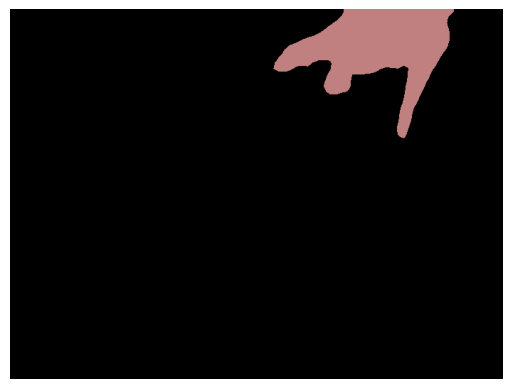

In [18]:
import torch
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchvision import models

# 1. 사전 학습된 DeepLabV3+ 모델 로드 (COCO dataset에서 사전 학습됨)
model = models.segmentation.deeplabv3_resnet50(pretrained=True)
model.eval()  # 평가 모드로 설정 (학습을 하지 않으므로)

# 2. 이미지 전처리 함수 정의
def preprocess(image_path):
    input_image = Image.open(image_path).convert("RGB")  # 이미지 로드 및 RGB 변환
    preprocess_transform = T.Compose([
        T.Resize(520),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # 사전 학습된 모델의 normalization
    ])
    input_tensor = preprocess_transform(input_image)
    input_batch = input_tensor.unsqueeze(0)  # 배치 차원 추가
    return input_batch

# 3. 세그멘테이션 결과 시각화 함수 정의
def decode_segmap(image, num_classes=21):
    label_colors = np.array([(0, 0, 0), (128, 0, 0), (0, 128, 0), (128, 128, 0), (0, 0, 128),
                             (128, 0, 128), (0, 128, 128), (128, 128, 128), (64, 0, 0), (192, 0, 0),
                             (64, 128, 0), (192, 128, 0), (64, 0, 128), (192, 0, 128), (64, 128, 128),
                             (192, 128, 128), (0, 64, 0), (128, 64, 0), (0, 192, 0), (128, 192, 0), (0, 64, 128)])
    
    r = np.zeros_like(image).astype(np.uint8)
    g = np.zeros_like(image).astype(np.uint8)
    b = np.zeros_like(image).astype(np.uint8)
    
    for l in range(0, num_classes):
        idx = image == l
        r[idx] = label_colors[l, 0]
        g[idx] = label_colors[l, 1]
        b[idx] = label_colors[l, 2]
        
    rgb = np.stack([r, g, b], axis=2)
    return rgb

# 4. 예측 함수 정의
def predict(image_path):
    input_batch = preprocess(image_path)

    # GPU가 사용 가능하면 모델과 데이터를 GPU로 이동
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    input_batch = input_batch.to(device)

    # 모델로 예측 수행
    with torch.no_grad():
        output = model(input_batch)['out'][0]
    
    # 각 픽셀에 대한 가장 높은 점수의 클래스를 선택
    output_predictions = output.argmax(0).cpu().numpy()

    # 시각화
    seg_image = decode_segmap(output_predictions)
    
    plt.imshow(seg_image)
    plt.axis('off')
    plt.show()

# 5. 예측 수행
image_path = "/home/najo/NAS/RobotHuman_Co-work/datasets/Robot_data/Basler_acA1300-30gc__24051641__20240911_131710002_0497.tiff"  # 예측할 이미지 경로
predict(image_path)



0: 480x640 1 person, 1 toilet, 6.1ms
Speed: 2.0ms preprocess, 6.1ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
Pose landmarks detected!


W0000 00:00:1728290193.866226 1651745 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1728290193.922659 1651765 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/home/najo/.conda/envs/test_20240708/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


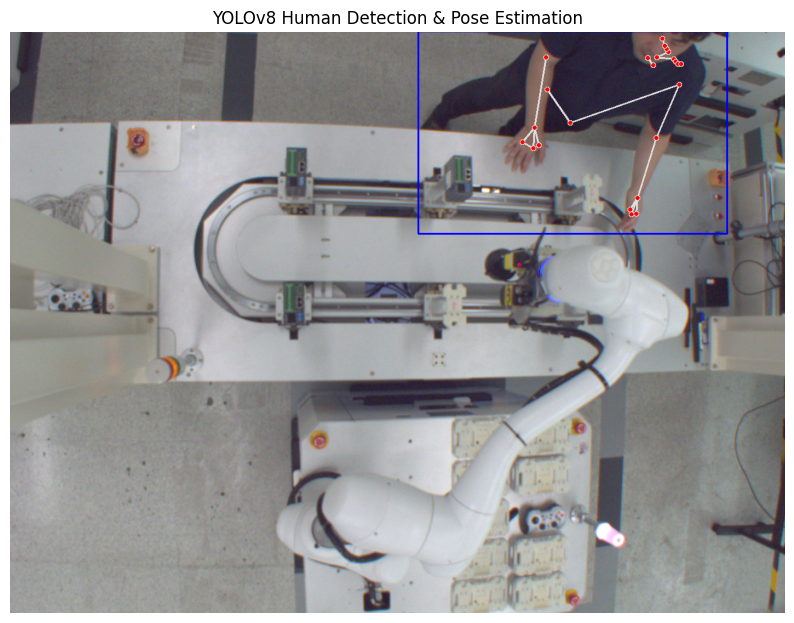

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import mediapipe as mp

# YOLO 모델 로드 (사람 탐지를 위한 pre-trained 모델 사용)
model = YOLO('yolov8n.pt')  # 경량 모델, 더 큰 모델을 원하면 yolov8s.pt, yolov8m.pt 등 사용 가능

# Mediapipe Pose 모델 초기화
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

# Mediapipe 그리기 도구 설정
mp_drawing = mp.solutions.drawing_utils

# TIFF 이미지 불러오기
image_path = '/home/najo/NAS/RobotHuman_Co-work/datasets/Robot_data/Basler_acA1300-30gc__24051641__20240911_131710002_0497.tiff'  # 사용할 TIFF 이미지 경로
image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)  # TIFF 파일 불러오기

# YOLO를 사용하여 사람 탐지
results = model(image)

# YOLO 탐지 결과 시각화 (Bounding Box 그리기)
for result in results:
    for box in result.boxes:
        # box.cls는 클래스 인덱스, box.xyxy는 경계 상자 좌표
        if int(box.cls[0]) == 0:  # 클래스 0은 '사람' (COCO 데이터셋 기준)
            x1, y1, x2, y2 = map(int, box.xyxy[0])  # 좌표 추출
            cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)  # Bounding Box 시각화

            # 사람 영역 잘라내기
            cropped_person = image[y1:y2, x1:x2]

            # Pose estimation 실행 (사람 영역에서)
            image_rgb = cv2.cvtColor(cropped_person, cv2.COLOR_BGR2RGB)
            result_pose = pose.process(image_rgb)
            
            if result_pose.pose_landmarks:
                print("Pose landmarks detected!")  # Pose가 감지된 경우 콘솔에 출력
                
                # Pose landmarks 시각화
                mp_drawing.draw_landmarks(
                    cropped_person,
                    result_pose.pose_landmarks,
                    mp_pose.POSE_CONNECTIONS)

                # 탐지된 사람에 원래 이미지에 다시 그리기
                image[y1:y2, x1:x2] = cropped_person
            else:
                print("No pose landmarks detected in this person region")

# BGR에서 RGB로 변환 (matplotlib는 RGB 포맷을 사용)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 이미지 시각화 (matplotlib 사용)
plt.figure(figsize=(10, 10))
plt.imshow(image_rgb)
plt.axis('off')  # 축 숨기기
plt.title('YOLOv8 Human Detection & Pose Estimation')
plt.show()
